# Quasi energy plots


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# lets me import from a different directory
import sys 
sys.path.append("/Users/archie/documents/year4/project/code")

import spin_tools.hamiltonians as hamiltonians
from spin_tools.gates import *
import spin_tools.quantum_tools as qt
from spin_tools.floquet_tools import ccd_floquet


steel_blue, plum = "#4682B4", "#B44682"
deep_magenta = "#C12769"


In [3]:
# Create a quantum system with a single qubit
natural_freq = 10# 10ghz   
driving_freq = 10
rabi_freq = 0.005


# CCD parameters
phi_0, epsilon_m, phase_freq, theta_m = 0, rabi_freq/4, rabi_freq, 0


# Integration parameters
# Integration parameters
tol = 10**-7
evaluation_points = 2000
evaluation_time = 8/(rabi_freq)

# iteration parameters
detunings = np.linspace(0, 4*rabi_freq, 1000)


quasi_energies = []

for detuning in detunings:

    quasi_energies.append(ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m))


          

<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
/var/folders/r1/4bsh28x136nb61xfvz5ly0dh0000gn/T/ipykernel_60264/1692927758.py:6: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(detunings*1000, quasi_energies[:, i]*1000, label=f'$\epsilon_{i}$', color=deep_magenta)


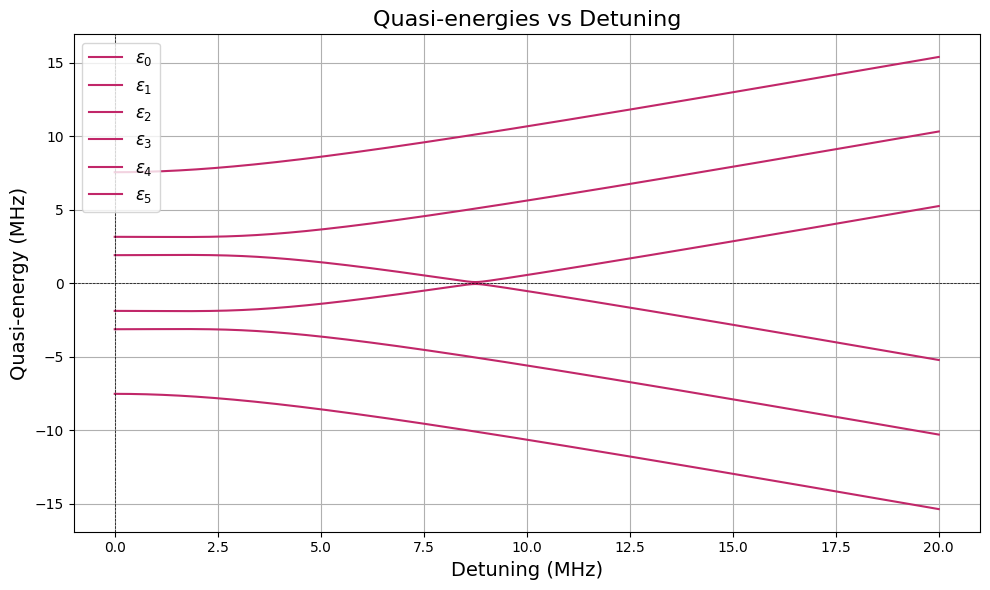

In [8]:
# plot the 6 quasi-energies against detuning
# quasi_energies is an array of arrays of the 6 quasi-energies at a given detuning
quasi_energies = np.array(quasi_energies)
plt.figure(figsize=(10, 6))
for i in range(6):
    plt.plot(detunings*1000, quasi_energies[:, i]*1000, label=f'$\epsilon_{i}$', color=deep_magenta)
plt.xlabel('Detuning (MHz)', fontsize=14)
plt.ylabel('Quasi-energy (MHz)', fontsize=14)
plt.title('Quasi-energies vs Detuning', fontsize=16)
plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
plt.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
plt.legend(fontsize=12)
plt.grid()
plt.tight_layout()
plt.savefig('/Users/archie/documents/year4/project/Figures/quasi_energies_vs_detuning', dpi=600)
plt.show()
#save the figure in the figures folder

